In [22]:
import torch
import torch.nn as nn
import math
import time
import os
import pandas as pd
from transformers import GPT2LMHeadModel, GPT2Tokenizer

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [25]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

baseline_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
baseline_model.eval()

print("Baseline loaded")

Baseline loaded


In [26]:
def kronecker_rank1(W, m1, m2, n1, n2):
    """
    W shape must be (m1*m2, n1*n2)
    """

    W = W.reshape(m1, m2, n1, n2)
    W = W.permute(0, 2, 1, 3).reshape(m1*n1, m2*n2)

    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    u = U[:, 0]
    v = Vh[0, :]
    s = S[0]

    A = (u * math.sqrt(s)).reshape(m1, n1)
    B = (v * math.sqrt(s)).reshape(m2, n2)

    return A.to(device), B.to(device)

In [27]:
class KronLinear(nn.Module):
    def __init__(self, A, B, bias, out_dim, in_dim):
        super().__init__()
        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)
        self.bias = nn.Parameter(bias.clone().to(device))

        self.out_dim = out_dim
        self.in_dim = in_dim

        self.m1, self.n1 = A.shape
        self.m2, self.n2 = B.shape

    def forward(self, x):
        batch, seq, dim = x.shape

        x = x.reshape(batch*seq, self.n1, self.n2)
        x = torch.matmul(x, self.B.t())
        x = torch.matmul(self.A, x)
        x = x.reshape(batch, seq, self.out_dim)

        return x + self.bias

In [28]:
def compress_one_layer(model, layer_idx):
    block = model.transformer.h[layer_idx]

    # -------- c_fc --------
    W_fc = block.mlp.c_fc.weight.data.to(device)
    b_fc = block.mlp.c_fc.bias.data.to(device)

    # 3072 x 768
    A_fc, B_fc = kronecker_rank1(
        W_fc,
        m1=48, m2=64,
        n1=12, n2=64
    )

    block.mlp.c_fc = KronLinear(
        A_fc, B_fc, b_fc,
        out_dim=3072,
        in_dim=768
    )

    # -------- c_proj --------
    W_proj = block.mlp.c_proj.weight.data.to(device)
    b_proj = block.mlp.c_proj.bias.data.to(device)

    # weight is 768 x 3072
    A_proj, B_proj = kronecker_rank1(
        W_proj,
        m1=12, m2=64,
        n1=48, n2=64
    )

    block.mlp.c_proj = KronLinear(
        A_proj, B_proj, b_proj,
        out_dim=768,
        in_dim=3072
    )

In [29]:
compressed_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
compressed_model.eval()

for i in range(12):
    compress_one_layer(compressed_model, i)

print("All layers compressed successfully.")

All layers compressed successfully.


In [30]:
dummy = tokenizer(
    "Artificial intelligence is amazing.",
    return_tensors="pt"
).to(device)

with torch.no_grad():
    out = compressed_model(**dummy)

print("Forward pass works. Logits shape:", out.logits.shape)

Forward pass works. Logits shape: torch.Size([1, 6, 50257])


In [31]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

baseline_params = count_parameters(baseline_model)
compressed_params = count_parameters(compressed_model)

print("Baseline params:", baseline_params)
print("Compressed params:", compressed_params)

Baseline params: 124439808
Compressed params: 67928832


In [32]:
torch.save(baseline_model.state_dict(), "baseline.pt")
torch.save(compressed_model.state_dict(), "compressed.pt")

print("Baseline size MB:", os.path.getsize("baseline.pt")/1024**2)
print("Compressed size MB:", os.path.getsize("compressed.pt")/1024**2)

Baseline size MB: 474.753586769104
Compressed size MB: 259.18871784210205


In [33]:
def measure_latency(model, runs=50):
    dummy = tokenizer(
        "Artificial intelligence is amazing.",
        return_tensors="pt"
    ).to(device)

    for _ in range(10):
        with torch.no_grad():
            model(**dummy)

    torch.cuda.synchronize()
    start = time.time()

    for _ in range(runs):
        with torch.no_grad():
            model(**dummy)

    torch.cuda.synchronize()
    end = time.time()

    return (end - start) / runs

print("Baseline latency ms:", measure_latency(baseline_model)*1000)
print("Compressed latency ms:", measure_latency(compressed_model)*1000)

Baseline latency ms: 10.215764045715332
Compressed latency ms: 11.470017433166504


In [35]:
def tokens_per_sec(model, runs=50):
    text = "Artificial intelligence is amazing."
    dummy = tokenizer(text, return_tensors="pt").to(device)
    tokens = dummy["input_ids"].shape[1]

    torch.cuda.synchronize()
    start = time.time()

    for _ in range(runs):
        with torch.no_grad():
            model(**dummy)

    torch.cuda.synchronize()
    end = time.time()

    return (tokens * runs) / (end - start)

print("Baseline TPS:", tokens_per_sec(baseline_model))
print("Compressed TPS:", tokens_per_sec(compressed_model))

Baseline TPS: 406.50516187308347
Compressed TPS: 466.0969598101076


In [37]:
import matplotlib.pyplot as plt
import numpy as np

In [38]:
baseline_params = 124439808
compressed_params = 67928832

baseline_size = 474.753586769104
compressed_size = 259.18871784210205

baseline_latency = 10.215764045715332
compressed_latency = 11.470017433166504

baseline_tps = 406.50516187308347
compressed_tps = 466.0969598101076

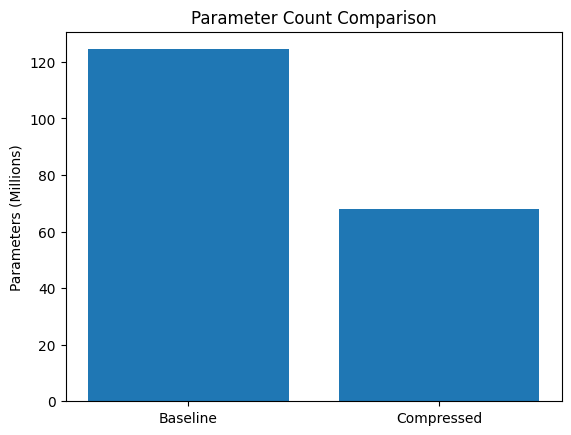

In [39]:
plt.figure()
plt.bar(["Baseline", "Compressed"],
        [baseline_params/1e6, compressed_params/1e6])

plt.ylabel("Parameters (Millions)")
plt.title("Parameter Count Comparison")
plt.show()

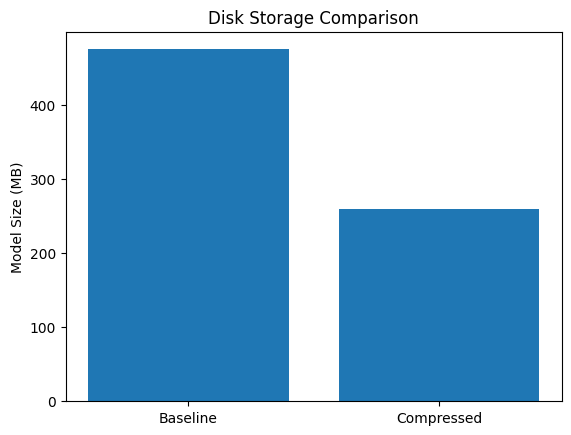

In [40]:
plt.figure()
plt.bar(["Baseline", "Compressed"],
        [baseline_size, compressed_size])

plt.ylabel("Model Size (MB)")
plt.title("Disk Storage Comparison")
plt.show()

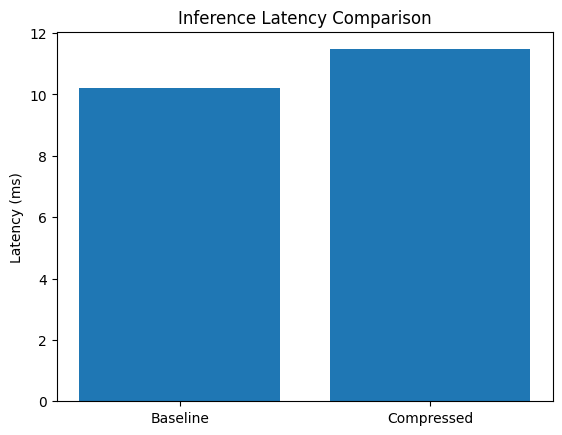

In [41]:
plt.figure()
plt.bar(["Baseline", "Compressed"],
        [baseline_latency, compressed_latency])

plt.ylabel("Latency (ms)")
plt.title("Inference Latency Comparison")
plt.show()

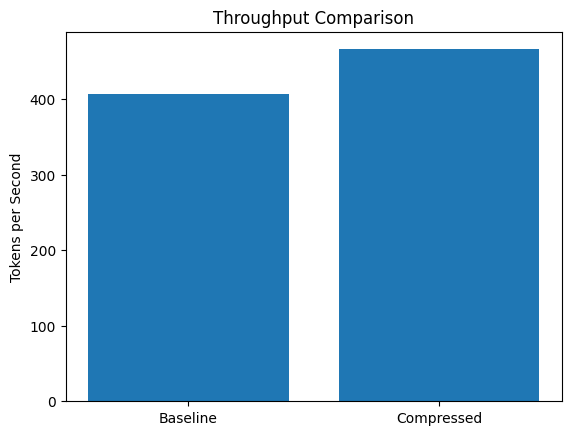

In [42]:
plt.figure()
plt.bar(["Baseline", "Compressed"],
        [baseline_tps, compressed_tps])

plt.ylabel("Tokens per Second")
plt.title("Throughput Comparison")
plt.show()

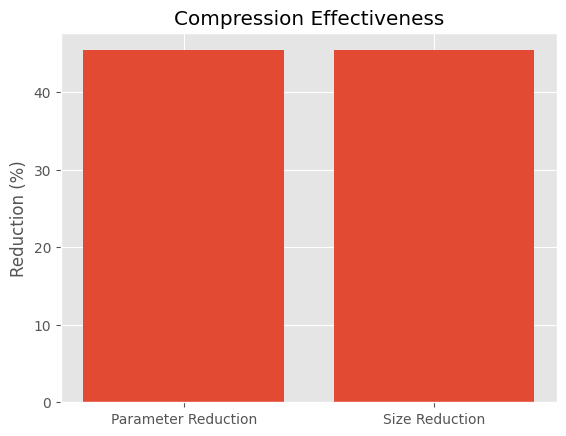

In [44]:
plt.style.use("ggplot")
param_reduction = (baseline_params - compressed_params) / baseline_params * 100
size_reduction = (baseline_size - compressed_size) / baseline_size * 100

plt.figure()
plt.bar(["Parameter Reduction", "Size Reduction"],
        [param_reduction, size_reduction])

plt.ylabel("Reduction (%)")
plt.title("Compression Effectiveness")
plt.show()

In [45]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("ggplot")

In [46]:
baseline_params = 124439808
compressed_params = 67928832

baseline_size = 474.753586769104
compressed_size = 259.18871784210205

baseline_latency = 10.215764045715332
compressed_latency = 11.470017433166504

baseline_tps = 406.50516187308347
compressed_tps = 466.0969598101076

In [47]:
# Normalize relative to baseline
param_ratio = compressed_params / baseline_params
size_ratio = compressed_size / baseline_size
latency_ratio = compressed_latency / baseline_latency
tps_ratio = compressed_tps / baseline_tps

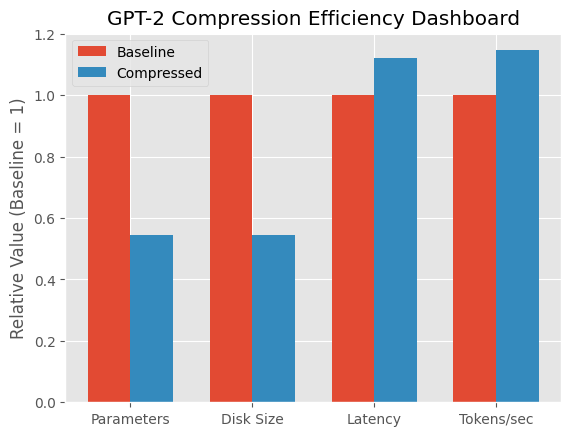

In [48]:
metrics = ["Parameters", "Disk Size", "Latency", "Tokens/sec"]

baseline_values = [1, 1, 1, 1]
compressed_values = [
    param_ratio,
    size_ratio,
    latency_ratio,
    tps_ratio
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, baseline_values, width, label="Baseline")
ax.bar(x + width/2, compressed_values, width, label="Compressed")

ax.set_ylabel("Relative Value (Baseline = 1)")
ax.set_title("GPT-2 Compression Efficiency Dashboard")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.show()